In [1]:
import pandas as pd

archivo = "Base1.2.xlsx"
xls = pd.ExcelFile(archivo)
dataset = pd.read_excel(archivo, sheet_name=xls.sheet_names[-2])

In [2]:
df = dataset.copy()
columnas_interes = ["1T Hemoglobina Glicada (NGSP/DCCT) (sangre total)", "1T Glucosa", "Diabetes franca 1T 0=no; 1=Si DF", "EdadFinal", "BMI (kg/m2)", "EtniaCod", "GDM1", "Factores Riesgo"]
columnas_derivadas = ["Obesidad BMI>30", "Edad≥35", "Gluc 1T>100", "Hba1c 1T>5,7"]
columnas_analitica1T = ["Hemoglobina Glicada (IFCC) (sangre total)", "Glucosa", "Hierro", "Ferritina", "Hemoglobina", "Hematocrito", "Volumen corpuscular medio", "Hemoglobina corpuscular media", "Transferrina", "Hematíes"]
df_completo = df[columnas_interes + columnas_analitica1T + columnas_derivadas]

In [3]:
import re
import unicodedata
import pandas as pd

def simplificar_columna(col):
    s = str(col).strip()

    # 1) Reglas específicas de negocio (prioridad alta)
    reglas = {
        "1T Hemoglobina Glicada (NGSP/DCCT) (sangre total)": "1T hemoglobina glicada",
        "Hemoglobina Glicada (IFCC) (sangre total)": "hemoglobina glicada ifcc",
        "Diabetes franca 1T 0=no; 1=Si DF": "diabetes franca 1T",
        "GDM1": "GDM1",
        "BMI (kg/m2)": "bmi",
        "EdadFinal": "edad",
        "EtniaCod": "etnia",
        "Obesidad BMI>30": "obesidad",
        "Edad≥35": "edad>=35",
    }
    if s in reglas:
        return reglas[s]

    # 2) Limpieza genérica para el resto
    s = re.sub(r"\([^)]*\)", "", s)      # elimina contenido entre paréntesis
    s = re.sub(r":.*$", "", s)           # elimina notas tras dos puntos

    # Normaliza acentos y espacios
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    s = re.sub(r"\s+", " ", s).strip().lower()

    return s

# Mapeo original -> simplificado
mapeo_columnas = {c: simplificar_columna(c) for c in df_completo.columns}

# Evita colisiones de nombres repetidos
contador = {}
for original, nuevo in list(mapeo_columnas.items()):
    if nuevo not in contador:
        contador[nuevo] = 1
    else:
        contador[nuevo] += 1
        mapeo_columnas[original] = f"{nuevo} ({contador[nuevo]})"

# DataFrame con columnas renombradas
df_manejable = df_completo.rename(columns=mapeo_columnas)

# Ver mapeo resultante
pd.Series(mapeo_columnas, name="columna_manejable")

1T Hemoglobina Glicada (NGSP/DCCT) (sangre total)           1T hemoglobina glicada
1T Glucosa                                                              1t glucosa
Diabetes franca 1T 0=no; 1=Si DF                                diabetes franca 1T
EdadFinal                                                                     edad
BMI (kg/m2)                                                                    bmi
EtniaCod                                                                     etnia
GDM1                                                                          GDM1
Factores Riesgo                                                    factores riesgo
Hemoglobina Glicada (IFCC) (sangre total)                 hemoglobina glicada ifcc
Glucosa                                                                    glucosa
Hierro                                                                      hierro
Ferritina                                                                ferritina
Hemo

In [4]:
df_manejable.describe()

,1T hemoglobina glicada,1t glucosa,diabetes franca 1T,bmi,GDM1,factores riesgo,hemoglobina glicada ifcc,glucosa,hierro,hemoglobina,hematocrito,volumen corpuscular medio,hemoglobina corpuscular media,transferrina,hematies
count,4444.000000,4441.000000,4444.000000,3511.000000,1956.000000,4444.000000,4444.000000,4441.000000,1399.000000,4435.000000,4435.000000,4435.000000,4435.000000,121.000000,4435.000000
mean,5.225383,77.314344,0.006526,26.943700,0.054703,0.688569,33.585509,77.167755,99.590422,12.931003,37.847418,86.490868,29.561443,282.603306,4.384328
std,0.363337,10.018172,0.080527,71.307610,0.227459,0.804973,3.995905,10.183475,35.866450,0.993786,2.662581,4.745729,2.029871,51.636144,0.345867
min,3.800000,37.000000,0.000000,9.295565,0.000000,0.000000,18.000000,37.000000,13.000000,5.500000,21.500000,58.900000,15.700000,179.000000,2.719919
25%,5.000000,72.000000,0.000000,21.873711,0.000000,0.000000,31.000000,72.000000,74.000000,12.400000,36.300000,84.300000,28.700000,243.000000,4.181716
50%,5.200000,77.000000,0.000000,24.609734,0.000000,1.000000,33.000000,76.000000,101.000000,13.000000,38.100000,86.800000,29.800000,279.000000,4.400000
75%,5.400000,82.000000,0.000000,28.746126,0.000000,1.000000,36.000000,81.000000,118.000000,13.500000,39.600000,89.500000,30.800000,315.000000,4.600000
max,10.900000,275.000000,1.000000,4239.669421,1.000000,5.000000,95.000000,275.000000,240.000000,16.300000,46.900000,105.000000,37.500000,465.000000,6.264090


In [5]:
import numpy as np
import pandas as pd

def normalizar_faltantes(df):
    df2 = df.copy()
    df2 = df2.replace(r"^\s*$", np.nan, regex=True)

    tokens_faltantes = {
        "no encuentra", "no encuentro", "no encontrado", "no encontrada",
        "nan", "na", "n/a", "null", "none", "s/d", "sin dato",
        "-", "--"
    }

    cols_obj = df2.select_dtypes(include=["object", "string", "category"]).columns
    for c in cols_obj:
        s = df2[c].astype("string").str.strip().str.lower()
        df2[c] = df2[c].where(~s.isin(tokens_faltantes), np.nan)

    return df2


def convertir_booleanos(df):
    df2 = df.copy()
    convertidas = []

    true_vals = {"true", "1", "si", "sí", "yes", "y", "t"}
    false_vals = {"false", "0", "no", "n", "f"}

    for c in df2.columns:
        s = df2[c]

        # 1) Candidatas texto/categoría
        if str(s.dtype) in ["object", "string", "category"]:
            x = s.astype("string").str.strip().str.lower()
            no_nulos = x.dropna()
            if no_nulos.empty:
                continue

            vals = set(no_nulos.unique().tolist())
            if vals.issubset(true_vals | false_vals):
                out = pd.Series(pd.NA, index=df2.index, dtype="boolean")
                out[x.isin(true_vals)] = True
                out[x.isin(false_vals)] = False
                df2[c] = out
                convertidas.append(c)
                continue

        # 2) Candidatas numéricas binarias (0/1)
        if pd.api.types.is_numeric_dtype(s):
            vals_num = set(pd.Series(s.dropna().unique()).tolist())
            if vals_num and vals_num.issubset({0, 1}):
                df2[c] = s.map({1: True, 0: False}).astype("boolean")
                convertidas.append(c)

    return df2, convertidas


def convertir_numericas(df, excluir=None, umbral=0.7, columnas_round=None, decimales_round=0):
    df2 = df.copy()
    excluir = set(excluir or [])
    columnas_round = set(columnas_round or [])

    cols_obj = df2.select_dtypes(include=["object", "string", "category"]).columns
    for c in cols_obj:
        if c in excluir:
            continue

        s = df2[c].astype("string").str.replace(",", ".", regex=False)
        convertido = pd.to_numeric(s, errors="coerce")
        ratio_num = convertido.notna().mean()

        if ratio_num >= umbral:
            if c in columnas_round:
                convertido = convertido.round(decimales_round)
                if decimales_round == 0:
                    convertido = convertido.astype("Int64")
            df2[c] = convertido

    return df2


# Pipeline SIN imputación
df_limpio = normalizar_faltantes(df_manejable)

# 1) Primero booleans
df_limpio, cols_booleanas = convertir_booleanos(df_limpio)

# 2) Columnas que deben mantenerse categóricas
cols_categoricas_fijas = {"factores riesgo"}

# 3) Luego numéricas, excluyendo booleanas y categóricas fijas
df_limpio = convertir_numericas(
    df_limpio,
    excluir=set(cols_booleanas) | cols_categoricas_fijas,
    columnas_round={"edad"},
    decimales_round=0
)

# 4) Forzar dtype category en categóricas fijas
for c in cols_categoricas_fijas:
    if c in df_limpio.columns:
        df_limpio[c] = df_limpio[c].astype("category")

print("Columnas convertidas a boolean:", cols_booleanas)
print("\nDtypes boolean:")
print(df_limpio[cols_booleanas].dtypes if cols_booleanas else "Ninguna")
print("\nDtypes categóricas fijas:")
print(df_limpio[list(cols_categoricas_fijas & set(df_limpio.columns))].dtypes)
print("\nFaltantes por columna:")
print(df_limpio.isna().sum().sort_values(ascending=False))

Columnas convertidas a boolean: ['diabetes franca 1T', 'etnia', 'GDM1', 'obesidad', 'edad>=35', 'gluc 1t>100', 'hba1c 1t>5,7']

Dtypes boolean:
diabetes franca 1T    boolean
etnia                 boolean
GDM1                  boolean
obesidad              boolean
edad>=35              boolean
gluc 1t>100           boolean
hba1c 1t>5,7          boolean
dtype: object

Dtypes categóricas fijas:
factores riesgo    category
dtype: object

Faltantes por columna:
transferrina                     4323
hierro                           3045
ferritina                        2952
GDM1                             2488
obesidad                         1449
bmi                               933
edad                              802
edad>=35                          802
etnia                             741
hematies                            9
hemoglobina                         9
hematocrito                         9
volumen corpuscular medio           9
hemoglobina corpuscular media       9
glucosa

In [6]:
# Imputa obesidad usando BMI > 30 solo cuando obesidad es nula
obesidad_bmi = pd.Series(pd.NA, index=df_limpio.index, dtype="boolean")
mask_bmi_valida = df_limpio["bmi"].notna()
obesidad_bmi.loc[mask_bmi_valida] = df_limpio.loc[mask_bmi_valida, "bmi"] > 30

df_limpio["obesidad"] = df_limpio["obesidad"].fillna(obesidad_bmi).astype("boolean")

print(df_limpio.isna().sum().sort_values(ascending=False))

transferrina                     4323
hierro                           3045
ferritina                        2952
GDM1                             2488
bmi                               933
obesidad                          933
edad                              802
edad>=35                          802
etnia                             741
hematies                            9
hemoglobina                         9
hematocrito                         9
volumen corpuscular medio           9
hemoglobina corpuscular media       9
glucosa                             3
gluc 1t>100                         3
1t glucosa                          3
1T hemoglobina glicada              0
hemoglobina glicada ifcc            0
factores riesgo                     0
diabetes franca 1T                  0
hba1c 1t>5,7                        0
dtype: int64


In [7]:
df_limpio.head()

,1T hemoglobina glicada,1t glucosa,diabetes franca 1T,edad,bmi,etnia,GDM1,factores riesgo,hemoglobina glicada ifcc,glucosa,...,hemoglobina,hematocrito,volumen corpuscular medio,hemoglobina corpuscular media,transferrina,hematies,obesidad,edad>=35,gluc 1t>100,"hba1c 1t>5,7"
0,5.5,70.0,False,<NA>,NaN,False,False,0,37,70.0,...,13.4,39.4,81.9,27.9,NaN,4.800000,<NA>,<NA>,False,False
1,5.6,80.0,False,37,21.484375,False,<NA>,1,38,80.0,...,12.3,36.6,92.2,31.0,NaN,3.969631,False,True,False,False
2,5.1,71.0,False,37,30.021502,False,False,2,32,71.0,...,13.5,38.6,87.1,30.5,NaN,4.400000,True,True,False,False
3,4.4,86.0,False,33,21.612812,False,<NA>,0,24,86.0,...,13.5,38.3,84.9,29.9,NaN,4.511190,False,False,False,False
4,5.2,70.0,False,36,21.155294,False,<NA>,1,33,70.0,...,12.8,37.8,84.6,28.6,NaN,4.468085,False,True,False,False


In [8]:
df_final = df_limpio[df_limpio["GDM1"].notna() & df_limpio["bmi"].notna() & df_limpio["edad"].notna() & df_limpio["1t glucosa"].notna() & df_limpio["etnia"].notna()]
df_final.head()

,1T hemoglobina glicada,1t glucosa,diabetes franca 1T,edad,bmi,etnia,GDM1,factores riesgo,hemoglobina glicada ifcc,glucosa,...,hemoglobina,hematocrito,volumen corpuscular medio,hemoglobina corpuscular media,transferrina,hematies,obesidad,edad>=35,gluc 1t>100,"hba1c 1t>5,7"
2,5.1,71.0,False,37,30.021502,False,False,2,32,71.0,...,13.5,38.6,87.1,30.5,NaN,4.400000,True,True,False,False
5,5.2,86.0,False,30,34.205830,False,False,1,33,86.0,...,13.0,38.6,87.1,29.3,NaN,4.431688,True,False,False,False
7,5.2,75.0,False,35,29.544707,False,False,2,33,75.0,...,13.6,39.5,87.0,30.0,NaN,4.500000,False,True,False,False
11,5.4,80.0,False,38,23.255814,False,False,1,36,80.0,...,13.5,38.7,85.4,29.8,NaN,4.500000,False,True,False,False
12,4.9,97.0,False,37,26.619343,False,False,1,30,97.0,...,14.9,41.7,89.1,31.8,NaN,4.700000,False,True,False,False


In [9]:
df_final.describe()

,1T hemoglobina glicada,1t glucosa,edad,bmi,hemoglobina glicada ifcc,glucosa,hierro,hemoglobina,hematocrito,volumen corpuscular medio,hemoglobina corpuscular media,transferrina,hematies
count,1879.000000,1879.000000,1879.0,1879.000000,1879.000000,1879.000000,627.000000,1876.000000,1876.000000,1876.000000,1876.000000,53.000000,1876.000000
mean,5.258861,78.215540,33.451836,29.060907,33.929750,78.049494,100.437002,12.989446,37.969829,86.528678,29.614179,278.962264,4.396190
std,0.301602,8.472524,6.001304,97.358829,3.307358,8.443901,36.148705,0.960231,2.585021,4.700525,2.011872,47.011849,0.338295
min,3.900000,54.000000,14.0,9.295565,19.000000,54.000000,16.000000,7.800000,24.100000,58.900000,18.400000,179.000000,2.900000
25%,5.100000,73.000000,30.0,22.308753,32.000000,73.000000,73.000000,12.500000,36.400000,84.300000,28.800000,245.000000,4.200000
50%,5.200000,78.000000,34.0,25.765713,34.000000,77.000000,101.000000,13.000000,38.100000,86.900000,29.800000,272.000000,4.400000
75%,5.400000,83.000000,38.0,30.821685,36.000000,83.000000,118.000000,13.600000,39.600000,89.400000,30.900000,315.000000,4.600000
max,7.100000,121.000000,52.0,4239.669421,54.000000,121.000000,240.000000,16.000000,45.800000,102.400000,36.500000,411.000000,6.264090


In [10]:
print(df_final.isna().sum().sort_values(ascending=False))

transferrina                     1826
hierro                           1252
ferritina                        1222
hemoglobina                         3
hematies                            3
hemoglobina corpuscular media       3
volumen corpuscular medio           3
hematocrito                         3
gluc 1t>100                         0
edad>=35                            0
obesidad                            0
1T hemoglobina glicada              0
1t glucosa                          0
glucosa                             0
hemoglobina glicada ifcc            0
factores riesgo                     0
GDM1                                0
etnia                               0
bmi                                 0
edad                                0
diabetes franca 1T                  0
hba1c 1t>5,7                        0
dtype: int64


In [11]:
df_sin_analisis = df_final.drop(columns=["hemoglobina", "hemoglobina glicada ifcc", "glucosa", "hematocrito", "volumen corpuscular medio", "hemoglobina corpuscular media", "transferrina", "hematies", "hierro", "ferritina"])
print(df_sin_analisis.isna().sum().sort_values(ascending=False))

1T hemoglobina glicada    0
1t glucosa                0
diabetes franca 1T        0
edad                      0
bmi                       0
etnia                     0
GDM1                      0
factores riesgo           0
obesidad                  0
edad>=35                  0
gluc 1t>100               0
hba1c 1t>5,7              0
dtype: int64


In [12]:
df_sin_analisis.describe()

,1T hemoglobina glicada,1t glucosa,edad,bmi
count,1879.000000,1879.000000,1879.0,1879.000000
mean,5.258861,78.215540,33.451836,29.060907
std,0.301602,8.472524,6.001304,97.358829
min,3.900000,54.000000,14.0,9.295565
25%,5.100000,73.000000,30.0,22.308753
50%,5.200000,78.000000,34.0,25.765713
75%,5.400000,83.000000,38.0,30.821685
max,7.100000,121.000000,52.0,4239.669421


In [13]:
# Calcular el porcentaje de GDM1 positivo
gdm1_counts = df_sin_analisis["GDM1"].value_counts()
gdm1_positive = gdm1_counts.get(True, 0)
gdm1_total = len(df_sin_analisis)
gdm1_percentage = (gdm1_positive / gdm1_total) * 100

print(f"Total de pacientes: {gdm1_total}")
print(f"GDM1 positivos (True): {gdm1_positive}")
print(f"GDM1 negativos (False): {gdm1_counts.get(False, 0)}")
print(f"Porcentaje de GDM1 positivo: {gdm1_percentage:.2f}%")

Total de pacientes: 1879
GDM1 positivos (True): 103
GDM1 negativos (False): 1776
Porcentaje de GDM1 positivo: 5.48%


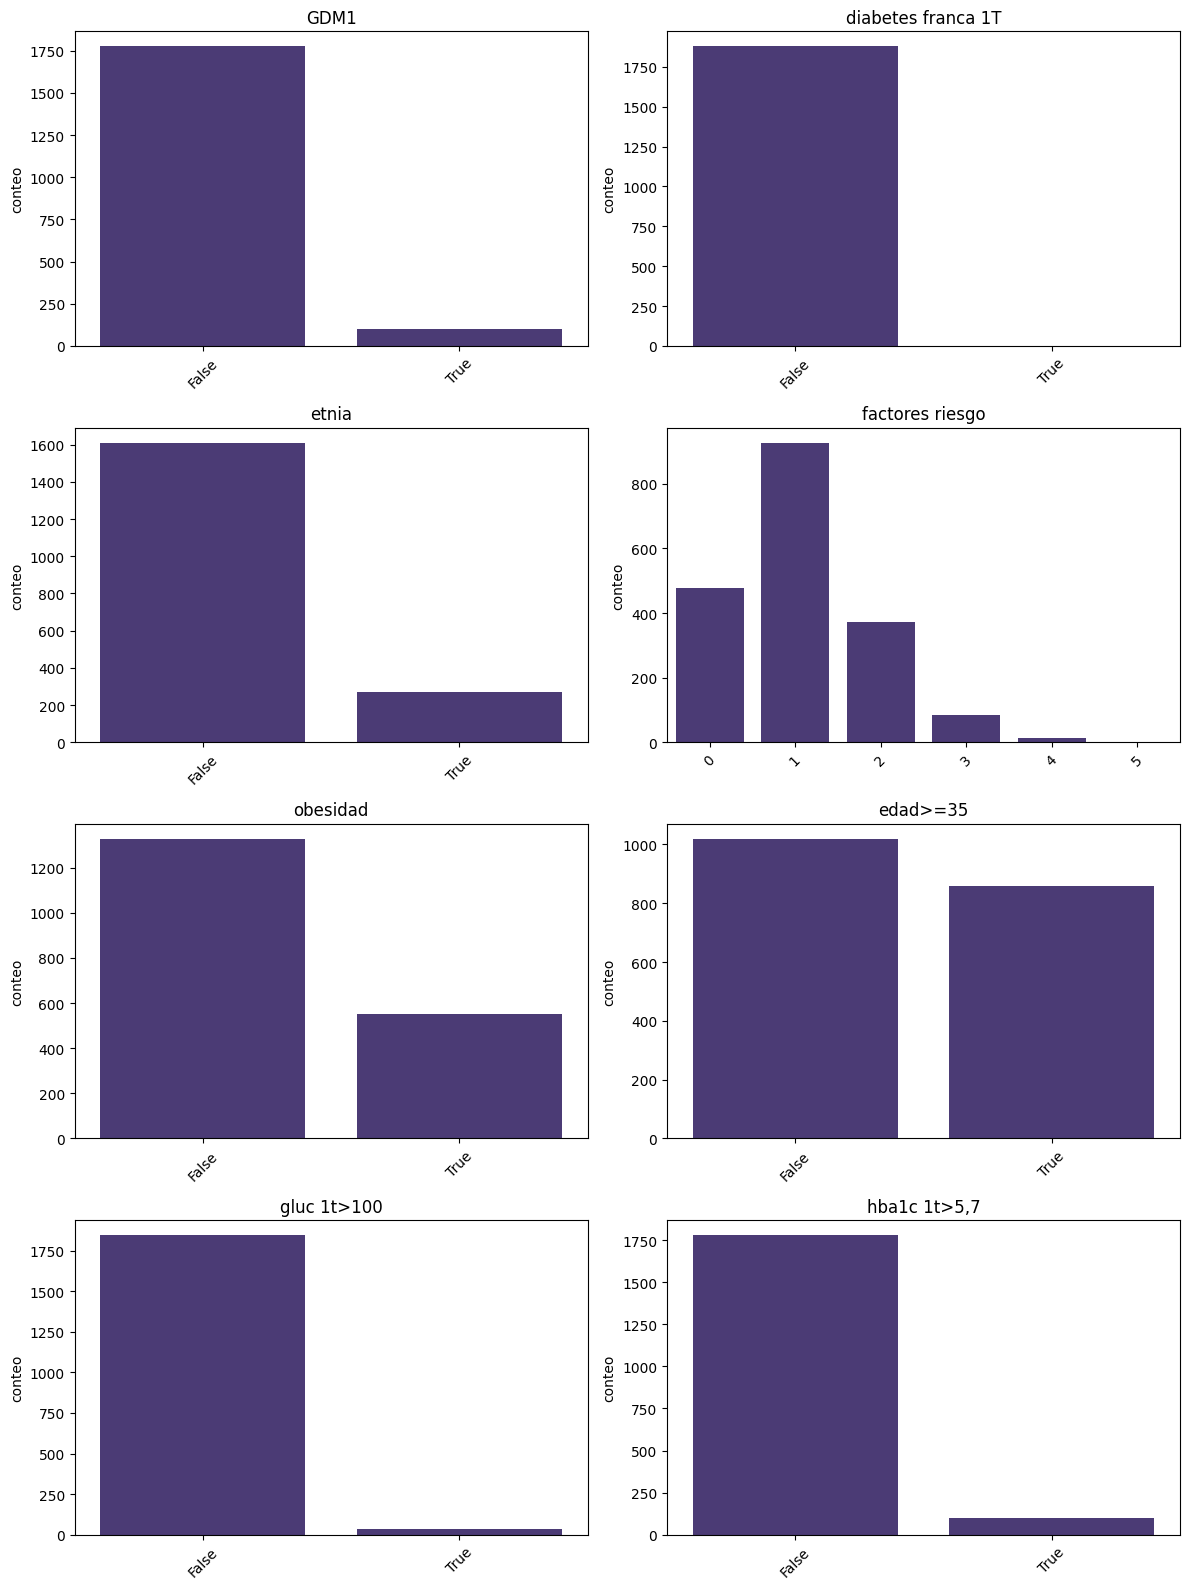

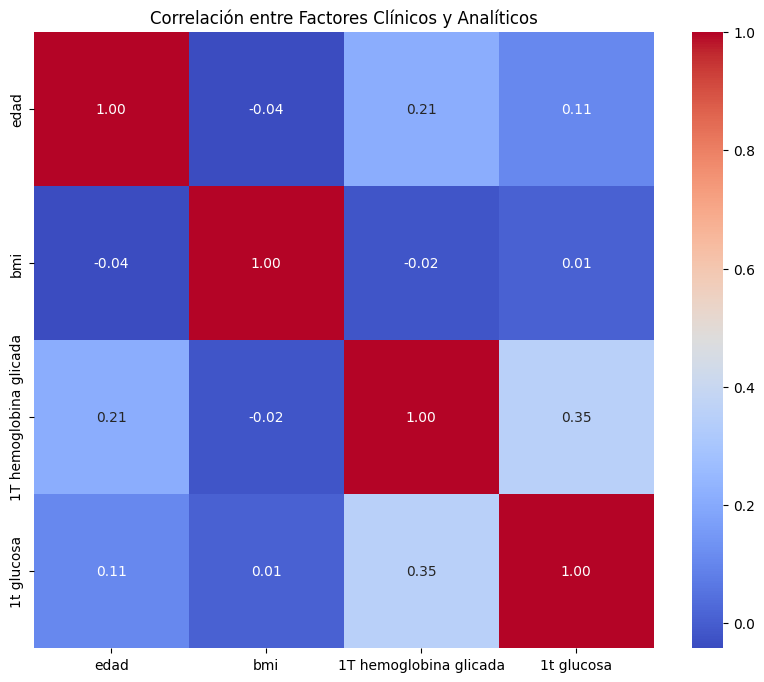

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Verificación del balance de la variable objetivo
# Variables categóricas y booleanas (incluye etnia)
cat_cols = [
    c for c in df_sin_analisis.columns
    if str(df_sin_analisis[c].dtype) in ("bool", "boolean", "object", "category")
]

# Coloca el target primero si existe
cat_cols = ["GDM1"] + [c for c in cat_cols if c != "GDM1"]

n = len(cat_cols)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.flatten()

color = sns.color_palette("viridis")[0]

for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df_sin_analisis, x=col, ax=ax, color=color)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("conteo")
    ax.tick_params(axis="x", rotation=45)

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()
# 2. Correlación de variables numéricas reales
# Usamos tus nombres exactos de la celda 68
cols_num = ['edad', 'bmi', '1T hemoglobina glicada', '1t glucosa']
plt.figure(figsize=(10, 8))
sns.heatmap(df_sin_analisis[cols_num].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación entre Factores Clínicos y Analíticos')
plt.show()

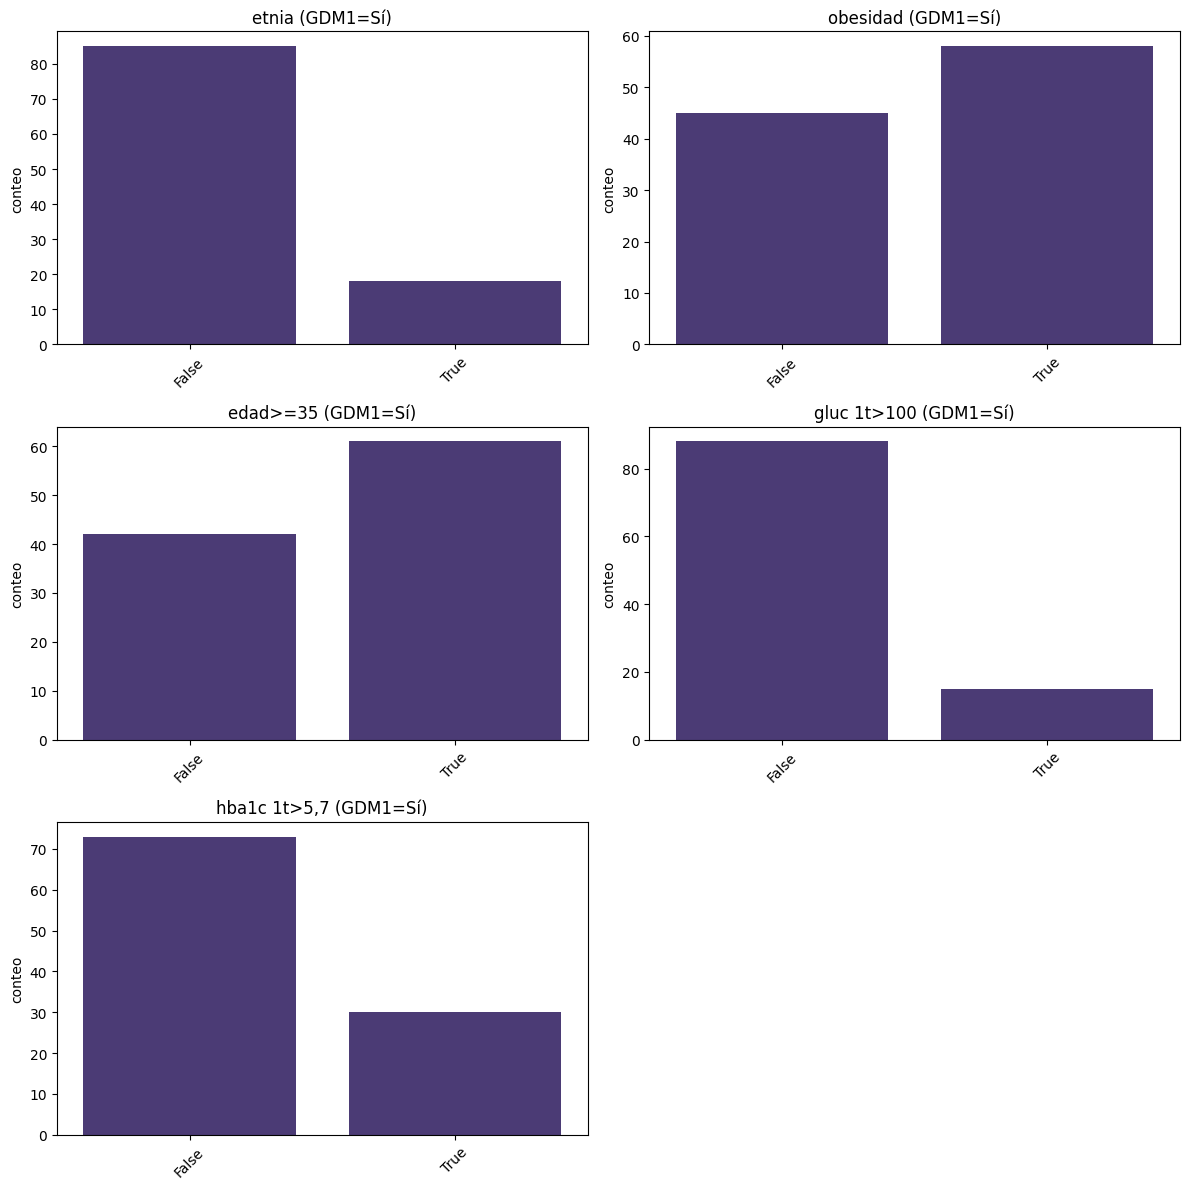


Total de pacientes con GDM1=True: 103


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrar solo los datos con GDM1 = True
df_gdm_positivos = df_sin_analisis[df_sin_analisis["GDM1"] == True].copy()

# Variables a mostrar (todas categóricas/binarias)
variables_mostrar = [
    "etnia",
    "obesidad",
    "edad>=35",
    "gluc 1t>100",
    "hba1c 1t>5,7"
]

# Verificar que todas las columnas existen
faltantes = [v for v in variables_mostrar if v not in df_gdm_positivos.columns]
if faltantes:
    print(f"Advertencia: Faltan columnas {faltantes}")
    variables_mostrar = [v for v in variables_mostrar if v in df_gdm_positivos.columns]

n = len(variables_mostrar)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.flatten()

color = sns.color_palette("viridis")[0]

for ax, col in zip(axes, variables_mostrar):
    sns.countplot(data=df_gdm_positivos, x=col, ax=ax, color=color)
    ax.set_title(f"{col} (GDM1=Sí)")
    ax.set_xlabel("")
    ax.set_ylabel("conteo")
    ax.tick_params(axis="x", rotation=45)

# Ocultar ejes sobrantes
for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

print(f"\nTotal de pacientes con GDM1=True: {len(df_gdm_positivos)}")

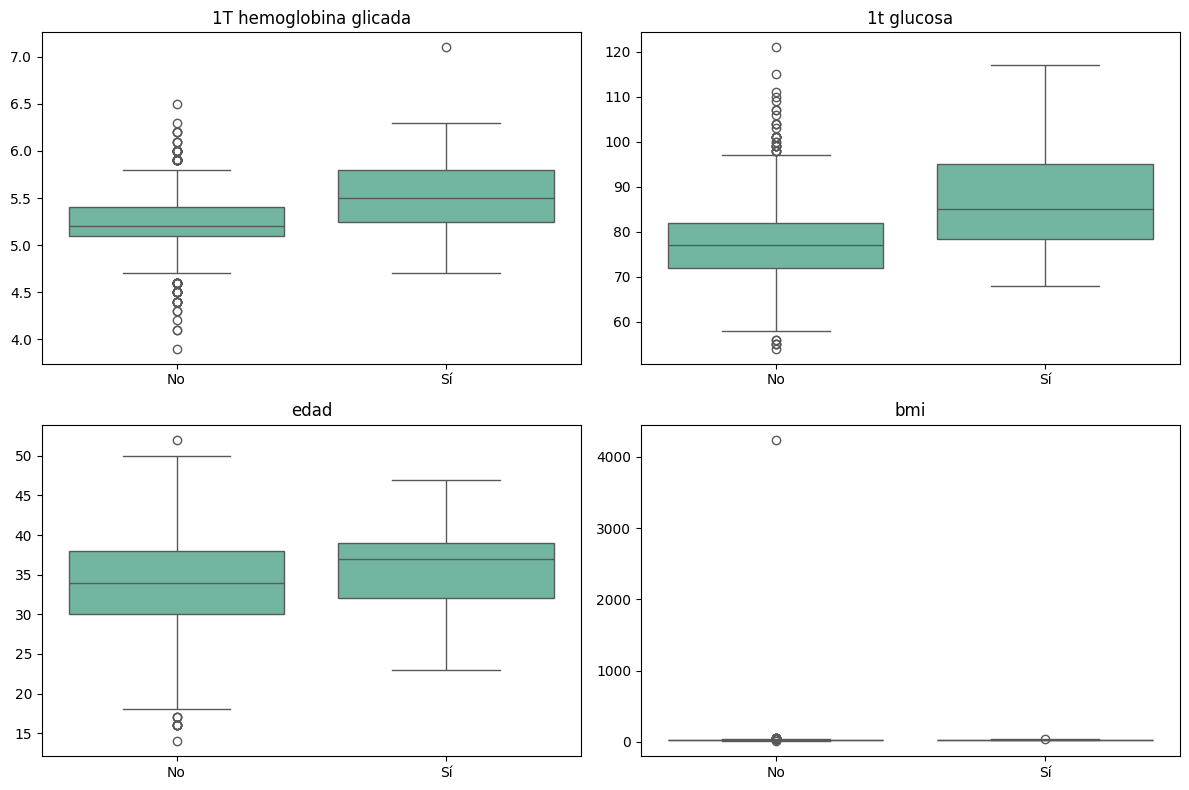

In [16]:
# Numéricas no binarias (excluye target y columnas con <=2 valores únicos)
numeric_cols = [
    c for c in df_sin_analisis.columns
    if c != "GDM1"
    and pd.api.types.is_numeric_dtype(df_sin_analisis[c])
    and not pd.api.types.is_bool_dtype(df_sin_analisis[c])
    and df_sin_analisis[c].dropna().nunique() > 2
]

df_box = df_sin_analisis[numeric_cols + ["GDM1"]].copy()
df_box["GDM1"] = df_box["GDM1"].map({False: "No", True: "Sí"})

n = len(numeric_cols)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df_box, x="GDM1", y=col, ax=ax, color=sns.color_palette("Set2")[0])
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

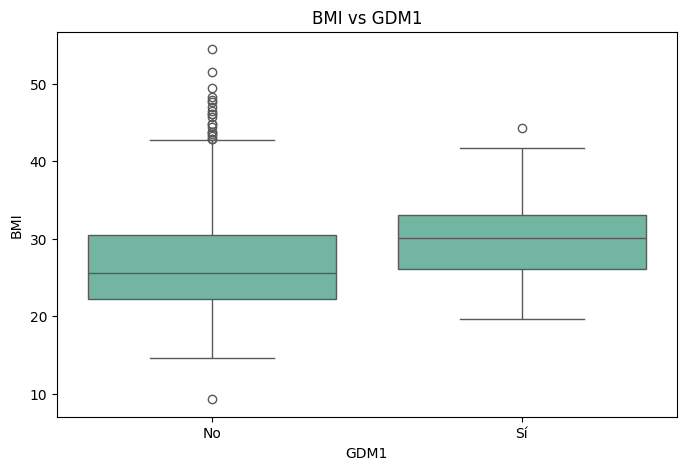

In [17]:
# Eliminar la fila con el BMI máximo y volver a graficar
df_sin_analisis = df_sin_analisis.drop(index=df_sin_analisis["bmi"].idxmax())
df_box = df_box.drop(index=df_box["bmi"].idxmax())

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_box, x="GDM1", y="bmi", color=sns.color_palette("Set2")[0])
plt.title("BMI vs GDM1")
plt.xlabel("GDM1")
plt.ylabel("BMI")
plt.show()

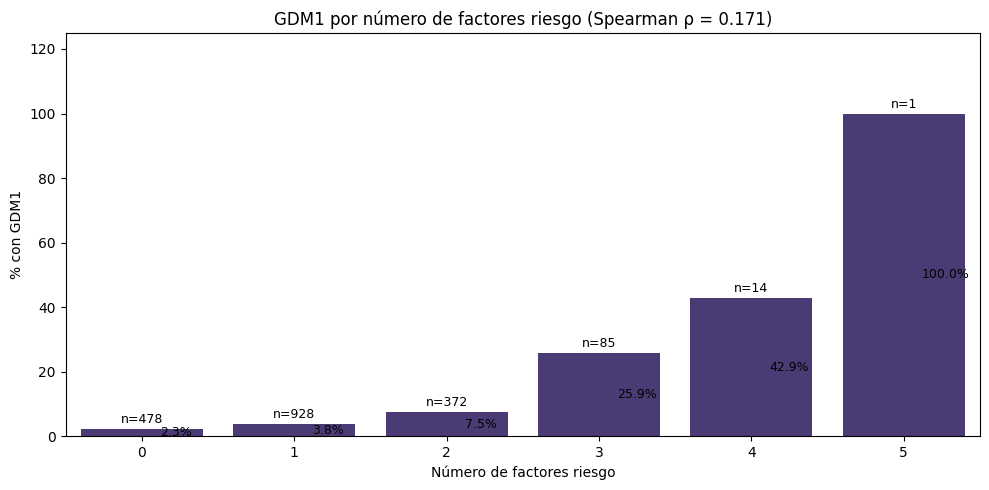

In [18]:
# Relación entre número de "factores riesgo" y "GDM1" (proporción de casos positivos)

df_plot = df_sin_analisis[["factores riesgo", "GDM1"]].copy()
df_plot["factores riesgo"] = pd.to_numeric(df_plot["factores riesgo"], errors="coerce").astype("Int64")
df_plot["GDM1"] = df_plot["GDM1"].astype("Int64")

resumen = (
    df_plot.dropna()
    .groupby("factores riesgo", as_index=False)
    .agg(
        n=("GDM1", "size"),
        prevalencia=("GDM1", "mean")
    )
    .sort_values("factores riesgo")
)

rho = df_plot.dropna()[["factores riesgo", "GDM1"]].corr(method="spearman").iloc[0, 1]

fig, ax1 = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=resumen,
    x="factores riesgo",
    y=resumen["prevalencia"] * 100,
    color=sns.color_palette("viridis")[0],
    ax=ax1
)
ax1.set_xlabel("Número de factores riesgo")
ax1.set_ylabel("% con GDM1")
ax1.set_title(f"GDM1 por número de factores riesgo (Spearman ρ = {rho:.3f})")
ax1.set_ylim(0, max((resumen["prevalencia"] * 100).max() * 1.25, 5))

for i, row in resumen.reset_index(drop=True).iterrows():
    pct = row["prevalencia"] * 100
    # n arriba de la barra
    ax1.text(i, pct + 0.8, f'n={int(row["n"])}', ha="center", va="bottom", fontsize=9)
    # porcentaje a la derecha de la barra
    ax1.text(i + 0.12, pct / 2, f'{pct:.1f}%', ha="left", va="center", fontsize=9, color="black")

plt.tight_layout()
plt.show()

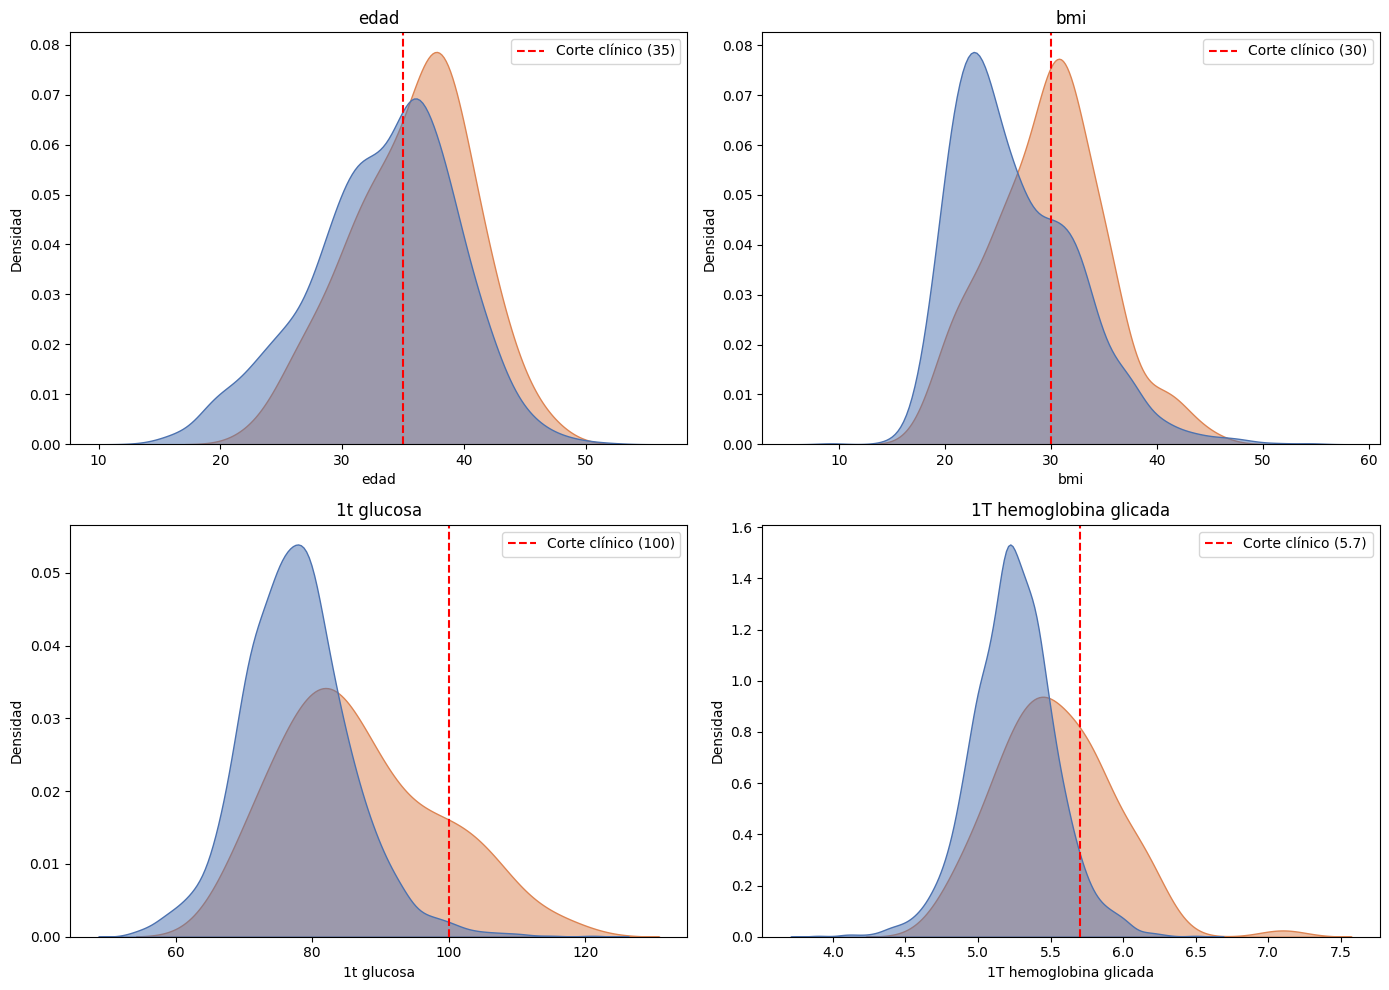

In [21]:
variables = {
    "edad": 35,
    "bmi": 30,
    "1t glucosa": 100,
    "1T hemoglobina glicada": 5.7
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

df_plot = df_sin_analisis.copy()
df_plot["estado"] = df_plot["GDM1"].map({False: "Sanas", True: "Diabéticas"})

for ax, (col, corte) in zip(axes, variables.items()):
    sns.kdeplot(
        data=df_plot,
        x=col,
        hue="estado",
        hue_order=["Sanas", "Diabéticas"],
        fill=True,
        common_norm=False,
        palette={"Sanas": "#4C72B0", "Diabéticas": "#DD8452"},
        alpha=0.5,
        ax=ax
    )

    ax.axvline(corte, color="red", linestyle="--", label=f"Corte clínico ({corte})")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Densidad")
    ax.legend(loc="best")

plt.tight_layout()
plt.show()


In [ ]:
df_clinico = df_sin_analisis[
    ["GDM1",
     "diabetes franca 1T",
     "etnia",
     "factores riesgo",
     "edad>=35",
     "obesidad",
     "gluc 1t>100",
     "hba1c 1t>5,7"]
    ].copy()

df_clinico.to_csv("df_clinico.csv", index=False)
df_sin_analisis.to_csv("df_sin_analisis.csv", index=False)